In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/Users/xd/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/xd/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


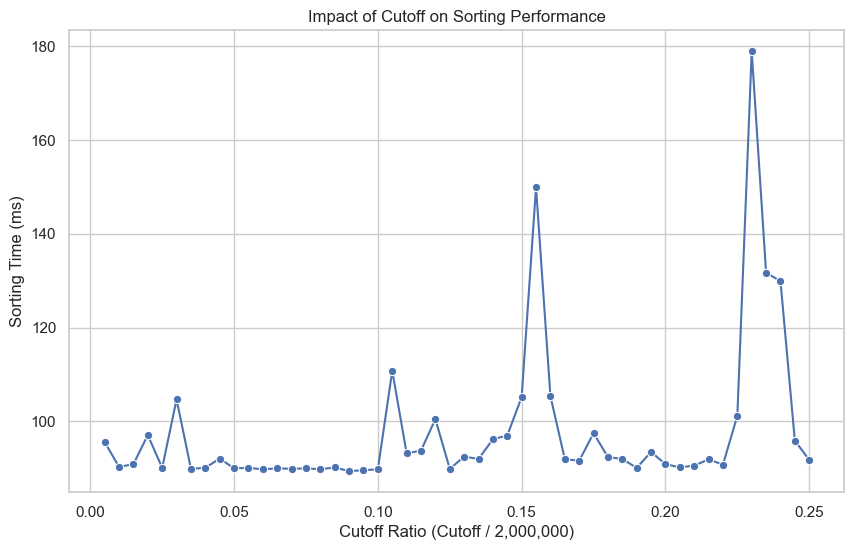

Optimal Cutoff Ratio:
Cutoff Ratio     0.09
Time (ms)       89.40
Name: 17, dtype: float64


In [11]:
df_fixed = pd.read_csv("result_fixed_array_size.csv", header=None, names=["Cutoff Ratio", "Time (ms)"])
sns.set(style="whitegrid")

# Plot sorting time vs. cutoff ratio
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_fixed, x="Cutoff Ratio", y="Time (ms)", marker="o", linestyle="-")
plt.xlabel("Cutoff Ratio (Cutoff / 2,000,000)")
plt.ylabel("Sorting Time (ms)")
plt.title("Impact of Cutoff on Sorting Performance")
plt.show()

# Identify optimal cutoff ratio
optimal_cutoff = df_fixed.loc[df_fixed["Time (ms)"].idxmin()]
print("Optimal Cutoff Ratio:")
print(optimal_cutoff)


In this fixed sized array (N = 2,000,000), we can see a relatively stable performance for small cutoff ratios (<0.1), with the optimal cutoff ratio at 0.09. Then an inconsistent performance between cutoff ratios 0.1 to 0.17, with a sharp spike of sorting time around 0.15 to 0.17; then another relatively stable period around 0.18 to 0.22 and another sharp spike of sorting time around 0.23 to 0.25. The larger cutoffs may result in too few partitions and leaving some threads idle to increase the sorting time.

As we know that the tecursion depth, D, before switching to Arrays.sort() is D = log(N/cutoff), we know that lower/smaller cutoff gives us more recursion levels, which corresponds to the stable performance for small cutoff ratios (<0.1), and the optimal cutoff ratio at 0.09. In this period, our D >= log(N/0.1N) = lg10 ~ 3.5 giving us most D around 4 to 8 (our available max number of threads, ForkJoinPool.getCommonPoolParallelism() gives us 7, is 7 + 1 main thread on my computer) and as the performance between 0.05 to 0.1 are the best and the most stable, our ideal D might be around 4. Since the optimal cutoff ratio located at 0.09, our ideal D around 3 to 4 gives us a suggested ideal t = 2^D ~ 2^3 to 2^4, limited by the available threads t = 8, utilizing all t = 8 (7+1) threads efficiently.

Now we'll modify array size and t to see different array sizes and different cutoff schemes:

In [16]:
df = pd.read_csv("result.csv")

df.head()

,ArraySize,Threads,Cutoff,Time(ms)
0,2000000,1,2000000,128
1,2000000,2,1000000,93
2,2000000,4,500000,72
3,2000000,8,250000,75
4,2000000,16,125000,75


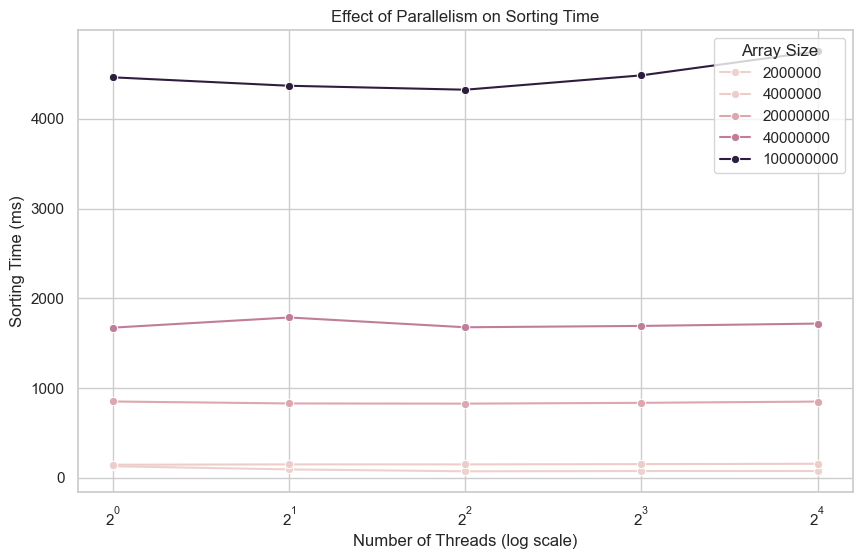

In [17]:

# Plot execution time vs. thread count for different array sizes
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Threads", y="Time(ms)", hue="ArraySize", marker="o")
plt.xscale("log", base=2)  # Use log scale for better visualization
plt.xlabel("Number of Threads (log scale)")
plt.ylabel("Sorting Time (ms)")
plt.title("Effect of Parallelism on Sorting Time")
plt.legend(title="Array Size")
plt.show()

it's too hard to read the difference between different number of threads for a given array size, we'll seperate the plots.

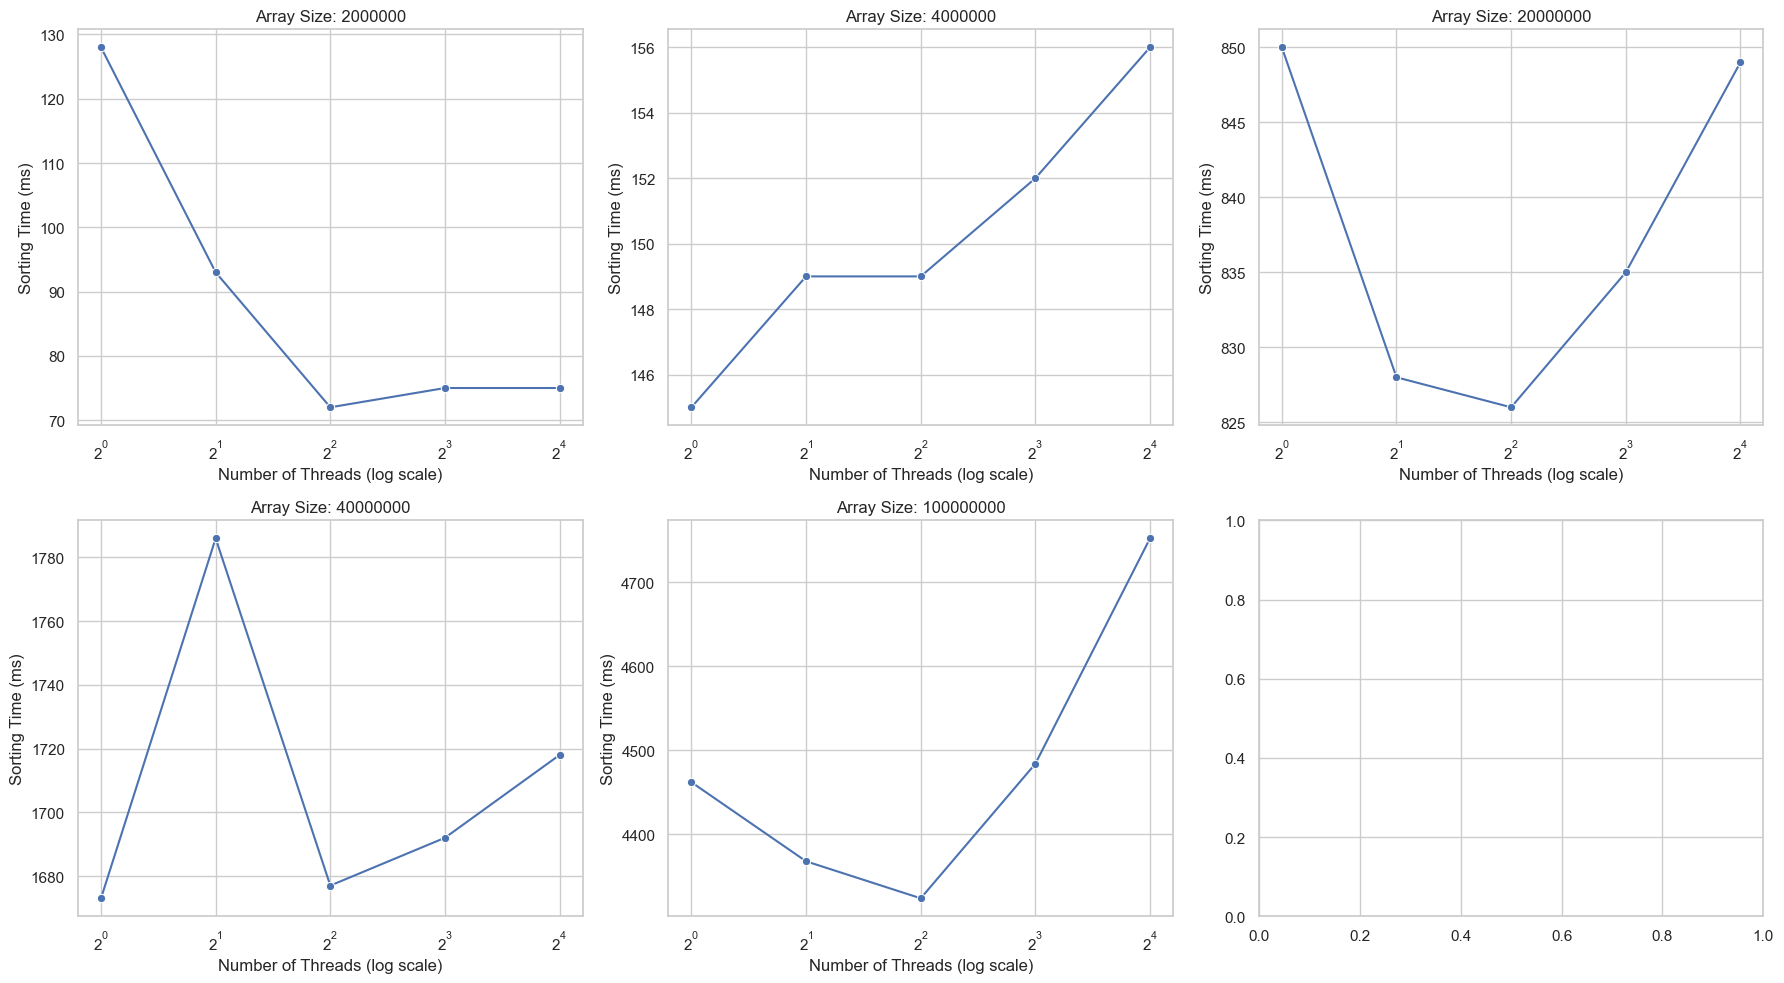

In [18]:
array_sizes = df["ArraySize"].unique()

# Create separate plots for each array size
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, size in enumerate(array_sizes):
    subset = df[df["ArraySize"] == size]
    sns.lineplot(ax=axes[i], data=subset, x="Threads", y="Time(ms)", marker="o")
    axes[i].set_xscale("log", base=2)
    axes[i].set_xlabel("Number of Threads (log scale)")
    axes[i].set_ylabel("Sorting Time (ms)")
    axes[i].set_title(f"Array Size: {size}")

plt.tight_layout()
plt.show()

For most array sizes tested: sorting time increases after t > 2^2 = 4, suggesting that more threads start creating overhead instead of speeding up sorting and parallelism provides speeding until task scheduling overhead cancels out benefits.

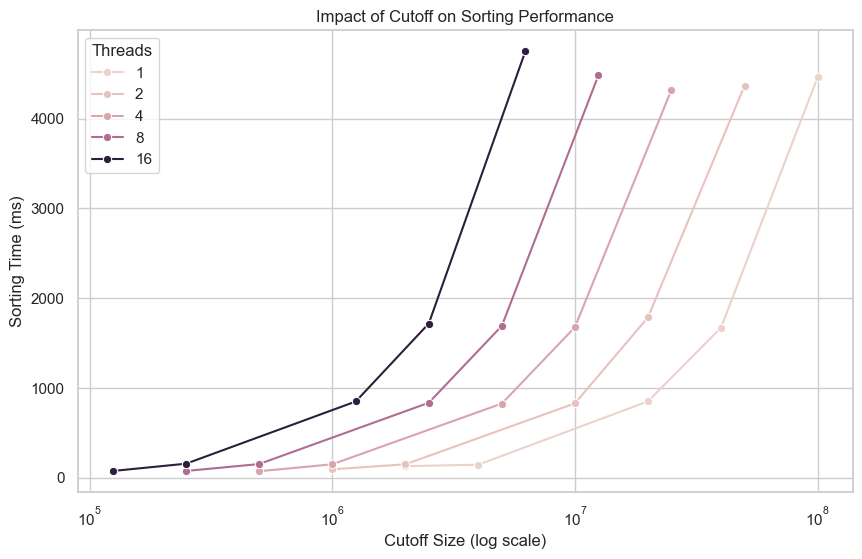

In [20]:
plt.figure(figsize=(10, 6))
#sns.scatterplot(data=df, x="Cutoff", y="Time(ms)", hue="Threads", palette="viridis")
sns.lineplot( data=df, x="Cutoff", y="Time(ms)",hue="Threads", marker="o")
plt.xscale("log")
plt.xlabel("Cutoff Size (log scale)")
plt.ylabel("Sorting Time (ms)")
plt.title("Impact of Cutoff on Sorting Performance")
plt.legend(title="Threads")
plt.show()

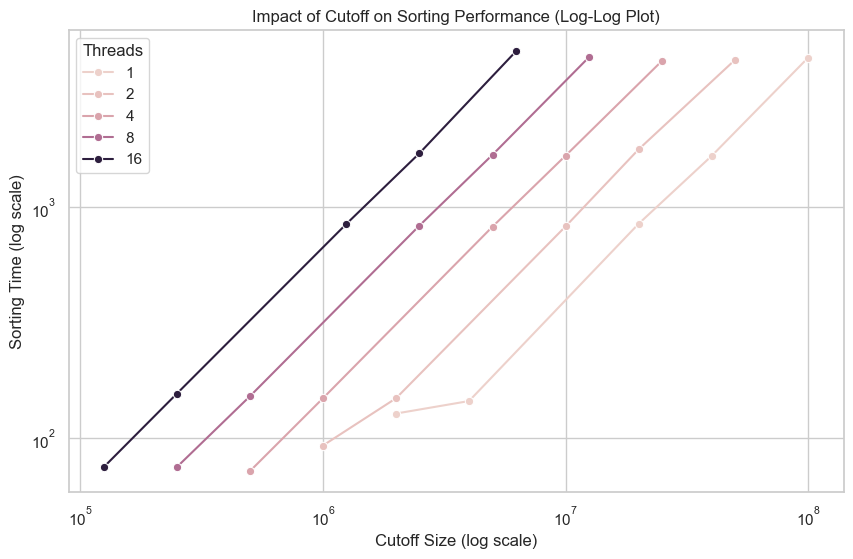

Optimal Thread Count for Each Array Size:
    ArraySize  Threads  Time(ms)
2     2000000        4        72
5     4000000        1       145
12   20000000        4       826
15   40000000        1      1673
22  100000000        4      4324


In [22]:

# Plot log-log plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Cutoff", y="Time(ms)", hue="Threads", marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Cutoff Size (log scale)")
plt.ylabel("Sorting Time (log scale)")
plt.title("Impact of Cutoff on Sorting Performance (Log-Log Plot)")
plt.legend(title="Threads")
plt.show()

# Identify optimal thread count per array size
optimal_threads = df.loc[df.groupby("ArraySize")["Time(ms)"].idxmin()][["ArraySize", "Threads", "Time(ms)"]]
print("Optimal Thread Count for Each Array Size:")
print(optimal_threads)

This result confirms our earlier observation that in parallelism (t > 1) helps, especially for t = 4 which gives most effective balance. But for some arrays (4M and 40M) performed best with t = 1, suggesting that parallelism is not always beneficial—likely due to threading and task scheduling overhead.

Comparing this result to the fixed-size array result, we can tell that cutoff size must be carefully tuned: in our dynamic cutoff (= N/t) experiment, higher t can lead to worse performance.